# RL Group Project: Starter Notebook
## Clinical Treatment Optimisation: Sepsis ICU Management

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This project is structured in two stages of increasing complexity.

- In **Configuration A**, you will work with a tabular Sepsis MDP, where the state and action spaces are small enough to apply classical RL methods directly. 

- In **Configuration B**, you will move to a continuous-observation ICU environment that is clinically grounded and significantly more challenging. 

Three realistic failure modes are present in Configuration B, each reflecting a real scenario encountered in clinical AI deployments. The first is episodic observation noise, where monitoring equipment occasionally malfunctions. The second is episodic missing observations, representing situations where lab results are simply unavailable for an entire episode. The third is acute clinical events, which are sudden and irreversible patient deteriorations that occur independently of any treatment given.


---
### Group Members
Fill in before submitting:

Name of the Group: Group X

```
Student 1: 
Student 2: 
Student 3: 
Student 4: 
Student 5: 
```


## 0. Setup & Imports


In [ ]:
# Install dependencies (run once)
# !pip install icu-sepsis numpy pandas matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
import sys

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'

SEED = 42
np.random.seed(SEED)

#  Import constants and env factory from env_setup.py 
from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print('Setup complete!')

ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# Configuration already loaded from env_setup.py
# env_setup.py defines: SOFA_BIAS=5.0, LAM=0.02, INTENSITY, make_sepsis_env()
print(f'Required config: sofa_bias={SOFA_BIAS}, lam={LAM}')

Required config: sofa_bias=5.0, lam=0.02


---
## 1. Explore the Environment

Before writing any algorithm, take time to understand the MDP you are working with. The insights you gain here should inform your report's Methodology section.

`ICU-Sepsis-v2` is a benchmark MDP constructed from real MIMIC-III patient data. Each episode represents the trajectory of one ICU patient. The agent observes a discrete integer state (ranging from 0 to 715) and must select one of 25 treatment actions corresponding to combinations of vasopressor and IV fluid dose levels. The reward signal is sparse: **+1 at survival, 0 at death, and 0 for all intermediate steps**, with a discount factor γ = 1.


In [ ]:
#  Instantiate and inspect the raw environment 
env = make_sepsis_env()
obs, info = env.reset(seed=SEED)

print(f'Observation space : {env.observation_space} discrete integer state')
print(f'Action space      : {env.action_space}')
print(f'Initial state     : {obs}')
print()

#  Extract the full MDP model 
raw = env.unwrapped
P = raw._tx_mat    # shape (716, 25, 716) — P[s,a,s'] = P(s'|s,a)
R_sasp = raw._r_mat                    # (716, 25, 716) — R[s, a, s']
R = (P * R_sasp).sum(axis=2)          # (716, 25)      — E[r | s, a]

print(f'Transition matrix P : {P.shape}  (S × A × S\')')
print(f'Reward matrix R     : {R.shape}  (S × A)')
print(f'Reward range        : [{R.min():.3f}, {R.max():.3f}]')
print()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Observation space : Discrete(716) discrete integer state
Action space      : Discrete(25)
Initial state     : 559

Transition matrix P : (716, 25, 716)  (S × A × S')
Reward matrix R     : (716, 25)  (S × A)
Reward range        : [-0.020, 0.708]



In [ ]:
#  Random baseline: establish the performance floor 
def run_random_baseline(n_episodes=1000, seed=SEED):
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            obs, r, te, tr, _ = env_eval.step(env_eval.action_space.sample())
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)
    env_eval.close()
    return np.array(returns), np.array(lengths)


rand_returns, rand_lengths = run_random_baseline()
survival_rate = float(np.mean(rand_returns > 0)) * 100

print(f'Random agent ({len(rand_returns)} episodes):')
print(f'  Mean return    : {np.mean(rand_returns):.4f}')
print(f'  Survival rate  : {survival_rate:.1f}%')
print(f'  Mean ep length : {np.mean(rand_lengths):.1f} steps')
print()
print('All Config A algorithms must beat the random baseline.')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Random agent (1000 episodes):
  Mean return    : 0.6014
  Survival rate  : 70.2%
  Mean ep length : 10.1 steps

All Config A algorithms must beat the random baseline.


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


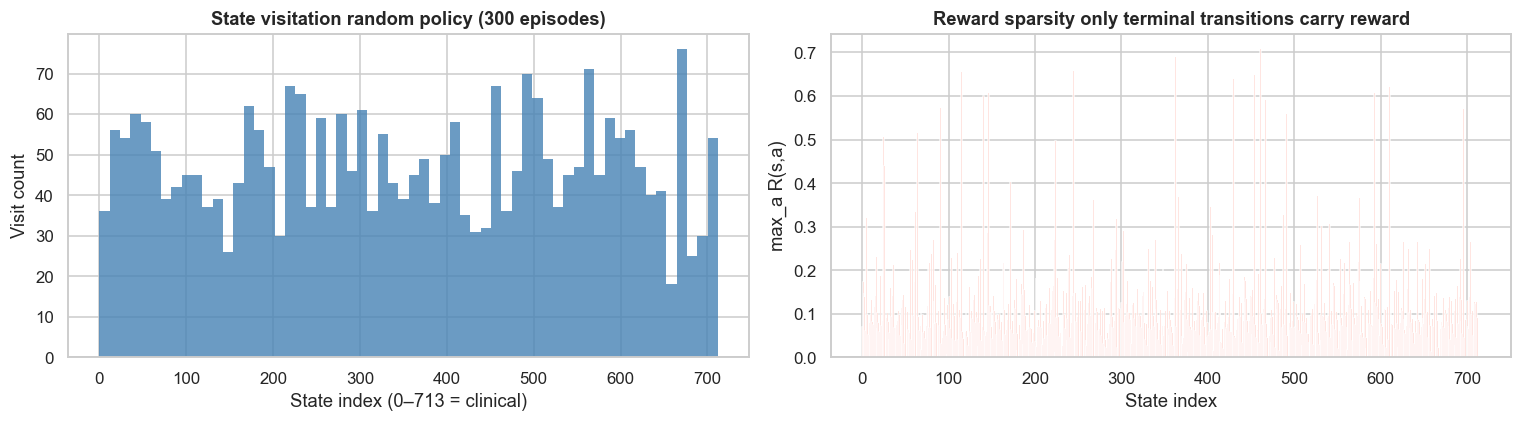

In [ ]:
#  Visualise state visitation and reward structure 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# State visitation under random policy
np.random.seed(SEED)
env_vis = make_sepsis_env()
visited = []
for _ in range(300):
    obs, _ = env_vis.reset(seed=np.random.randint(100_000))
    done = False
    while not done:
        visited.append(int(obs))
        obs, _, te, tr, _ = env_vis.step(env_vis.action_space.sample())
        done = te or tr
env_vis.close()
clinical = [s for s in visited if s not in (STATE_SURVIVED, STATE_DIED)]

axes[0].hist(clinical, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('State index (0–713 = clinical)')
axes[0].set_ylabel('Visit count')
axes[0].set_title('State visitation random policy (300 episodes)', fontweight='bold')

# Max achievable reward per state (only survival-adjacent states have r > 0)
axes[1].bar(range(N_STATES), R.max(axis=1), color='tomato', width=1.0, alpha=0.8)
axes[1].set_xlabel('State index')
axes[1].set_ylabel('max_a R(s,a)')
axes[1].set_title('Reward sparsity only terminal transitions carry reward',
                  fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_env_exploration.png', bbox_inches='tight')
plt.show()

---
# Config A — Tabular Methods

## Why tabular RL works here

The `ICU-Sepsis-v2` environment has **716 discrete states** and **25 discrete actions**, giving a Q-table of only 17,900 entries — trivially small for modern hardware.  More importantly, the environment exposes the **full MDP model**: transition tensor `P[s,a,s']` *(shape 716×25×716)* and reward tensor `R[s,a,s']` *(shape 716×25×716)* via `env.unwrapped._tx_mat` and `env.unwrapped._r_mat`.

Having access to P and R enables **model-based** Dynamic Programming, which is exact and far more sample-efficient than model-free methods.   
We implement all three for comparison.

## Algorithms implemented

| Algorithm | Type | Uses P? | Update target | Key property |
|---|---|---|---|---|
| **Policy Iteration** | Model-based DP | Yes | Exact Bellman equation | Guaranteed optimal π* |
| **Q-Learning** | Model-free, off-policy TD | No | `r + γ max Q(s',a')` | Learns Q* regardless of behaviour |
| **SARSA** | Model-free, on-policy TD | No | `r + γ Q(s', a')`, a'~π | Conservative; clinically safer |

Policy Iteration is our **gold standard** (theoretical ceiling).  Q-Learning and SARSA show how well model-free methods recover that ceiling from pure interaction.

In [6]:
# Import tabular agents 

# All three agents and the shared evaluator live in envs/tabular_agents.py
# They expose a uniform interface:
#   agent.train(...)     → trains the agent; returns a history dict
#   agent.get_policy()   → (N_STATES,) int array of greedy actions
#   agent.get_Q()        → (N_STATES, N_ACTIONS) Q-value matrix

from envs.tabular_agents import PolicyIteration, QLearning, SARSA, evaluate_policy

print(f"State space : {N_STATES} discrete states")
print(f"Action space: {N_ACTIONS} actions  (5 vasopressor × 5 IV-fluid levels)")
print(f"Q-table size: {N_STATES * N_ACTIONS:,} entries — fully tabular")

State space : 716 discrete states
Action space: 25 actions  (5 vasopressor × 5 IV-fluid levels)
Q-table size: 17,900 entries — fully tabular


## Algorithm 1: Policy Iteration *(Model-Based Dynamic Programming)*

Alternate between two steps until the policy stops changing:

1. **Policy Evaluation** — solve for $V_π$ iteratively:  
   $V(s) ← Σ_{s'} P(s'|s,π(s)) · [R(s,a) + γ·V(s')]$  until $|ΔV| < θ$

2. **Policy Improvement** — update $π$ to be greedy w.r.t. $V_π$:  
   $π(s) ← argmax_a Σ_{s'} P(s'|s,a) · [R(s,a) + γ·V(s')]$

**Why PI here?**  Because we have P and R, we can compute the Bellman expectation exactly without interacting with the environment.  PI is guaranteed to converge to the **optimal policy π*** in a finite number of iterations for any finite MDP.

**Implementation detail:** Policy evaluation uses vectorised matrix operations (`P @ V`) instead of a state loop — roughly 100× faster on this 716-state MDP.

**γ = 1.0** — no time discounting, consistent with the ICU-Sepsis paper: **only the final outcome (survival/death) matters, not when it occurs**.

In [7]:
# Extract the full MDP model 

# P[s,a,s'] = P(s'|s,a)      shape (716, 25, 716)
# R[s,a]    = E[r | s,a]     shape (716, 25)
#   computed as Σ_{s'} P(s'|s,a) · R(s,a,s')

env_pi  = make_sepsis_env()
raw     = env_pi.unwrapped
P       = raw._tx_mat                       # (716, 25, 716)
R_sasp  = raw._r_mat                        # (716, 25, 716)
R       = (P * R_sasp).sum(axis=2)          # (716, 25)
env_pi.close()

print(f"P shape : {P.shape}   R shape : {R.shape}")
print(f"R range : [{R.min():.4f}, {R.max():.4f}]\n")



# Train 
pi_agent   = PolicyIteration(P, R, gamma=GAMMA, theta=1e-9) # theta=1e-9 ensures V_π is computed to near-machine-precision
pi_history = pi_agent.train(max_iterations=200, verbose=True)

print()
print(f"Converged      : {pi_history['policy_stable']}")
print(f"Total iters    : {pi_history['iterations']}")
print(f"Total PE sweeps: {sum(pi_history['eval_sweeps'])}")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
P shape : (716, 25, 716)   R shape : (716, 25)
R range : [-0.0200, 0.7076]

  PI iter   1 | eval sweeps: 196 | policy changed: True
  PI iter   2 | eval sweeps: 171 | policy changed: True
  PI iter   3 | eval sweeps: 158 | policy changed: True
  PI iter   4 | eval sweeps:  99 | policy changed: False

Policy Iteration converged after 4 iterations.

Converged      : True
Total iters    : 4
Total PE sweeps: 624


## Algorithm 2 — Q-Learning *(Model-Free, Off-Policy TD)*

**Update rule** *(Sutton & Barto 6.5)*

$Q(s,a) ← Q(s,a) + α · [r + γ · max_{a'} Q(s',a')  −  Q(s,a)]$

<br>

The bootstrap target is the **greedy** action in s', not the action actually taken.  This makes Q-Learning **off-policy**: it converges to Q* regardless of the exploratory behaviour policy used during training.

| Hyperparameter | Value | Rationale |
|---|---|---|
| α | 0.1 | Standard for tabular TD; balances speed vs stability |
| γ | 1.0 | No time discounting (ICU-Sepsis paper convention) |
| ε-start / ε-end | 1.0 → 0.05 | Full exploration early; 5% retained at convergence |
| ε-decay | 5,000 episodes | Linear; fast enough to converge, slow enough to explore |
| Training episodes | 10,000 | Empirically sufficient for this 716-state MDP |

**Exploration:** ε-greedy — with probability ε pick a random action, otherwise pick `argmax_a Q(s,a)`.

In [8]:
np.random.seed(SEED)

# Train Q-Learning
ql_agent = QLearning(
    n_states=N_STATES, n_actions=N_ACTIONS,
    alpha=0.1, gamma=GAMMA,
    epsilon_start=1.0, epsilon_end=0.05,
    epsilon_decay_steps=5_000,
    seed=SEED,
)

print("Training Q-Learning (10,000 episodes)...\n")
ql_history = ql_agent.train(n_episodes=10_000, eval_every=500,
                             eval_eps=300, verbose=True)
print("\nQ-Learning training complete.")

Training Q-Learning (10,000 episodes)...

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  QL ep    500 | ε=0.905 | greedy return=0.6004 | survival=66.3%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  QL ep   1000 | ε=0.810 | greedy return=0.5839 | survival=66.7%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  QL ep   1500 | ε=0.715 | greedy return=0.5694 | survival=66.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  QL ep   2000 | ε=0.620 | greedy return=0.5649 | survival=65.3%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  QL ep   2500 | ε=0.525 | greedy retu

## Algorithm 3 — SARSA *(Model-Free, On-Policy TD)*

**Update rule** *(Sutton & Barto 6.4)*

$Q(s,a) ← Q(s,a) + α · [r + γ · Q(s', a')  −  Q(s,a)]$

where **$a'$ is sampled from the same ε-greedy policy** being improved — not taken greedily.

**Key difference from Q-Learning: clinical conservatism**

Because SARSA's bootstrap target accounts for exploratory actions, it is **risk-averse near dangerous states**: if exploration around a high-dose action occasionally leads to patient death, SARSA down-weights that action.

> In the ICU context this is desirable: a physician prefers moderate doses confidently over extreme doses with uncertainty.  We expect SARSA to prescribe lower treatment intensities than Q-Learning while achieving similar survival rates.

Hyperparameters are identical to Q-Learning so the only difference is the update rule — a clean apples-to-apples comparison.

In [9]:
np.random.seed(SEED)

# Train SARSA
sarsa_agent = SARSA(
    n_states=N_STATES, n_actions=N_ACTIONS,
    alpha=0.1, gamma=GAMMA,
    epsilon_start=1.0, epsilon_end=0.05,
    epsilon_decay_steps=5_000,
    seed=SEED,
)

print("Training SARSA (10,000 episodes)...\n")
sarsa_history = sarsa_agent.train(n_episodes=10_000, eval_every=500,
                                   eval_eps=300, verbose=True)
print("\nSARSA training complete.")

Training SARSA (10,000 episodes)...

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  SA ep    500 | ε=0.905 | greedy return=0.6159 | survival=65.7%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  SA ep   1000 | ε=0.810 | greedy return=0.5998 | survival=66.3%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  SA ep   1500 | ε=0.715 | greedy return=0.5785 | survival=65.3%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  SA ep   2000 | ε=0.620 | greedy return=0.5873 | survival=66.3%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  SA ep   2500 | ε=0.525 | greedy return=0.

## Evaluation

Each policy is evaluated over **1,000 episodes** with `SEED=42` for reproducibility.

| Metric | Definition |
|---|---|
| **Mean Return** | Average episodic return (0 = death; ≈0.7 = survival after intensity penalty) |
| **Survival Rate** | Fraction of episodes where patient survives (return > 0) |
| **Mean Ep. Length** | Average number of treatment steps per episode |
| **Mean Intensity** | Average normalised treatment dose per step (0 = no treatment, 1 = max) |

The **Random Baseline** is the performance floor.  **Policy Iteration** is the theoretical ceiling (optimal policy).  Q-Learning and SARSA demonstrate how close model-free methods can get.

In [10]:
np.random.seed(SEED)
print("Evaluating all policies (1,000 episodes each)...\n")

# RANDOM BASELINE:
# A random policy assigns a uniformly random action to every state.
# This is the performance floor that all trained agents must beat.
rand_policy = np.random.randint(0, N_ACTIONS, size=N_STATES)
rand_result  = evaluate_policy(rand_policy,         n_episodes=1_000, seed=SEED)


# TRAINED AGENTS:
pi_policy    = pi_agent.get_policy()
pi_result    = evaluate_policy(pi_policy,            n_episodes=1_000, seed=SEED)

ql_policy    = ql_agent.get_policy()
ql_result    = evaluate_policy(ql_policy,            n_episodes=1_000, seed=SEED)

sarsa_policy = sarsa_agent.get_policy()
sarsa_result = evaluate_policy(sarsa_policy,         n_episodes=1_000, seed=SEED)


# SUMMARY TABLE:
header = f"{'Algorithm':<22} {'Return':>8} {'Survival':>10} {'Ep.Len':>8} {'Intensity':>11}"
print("=" * len(header))
print(header)
print("-" * len(header))
for name, res in [
    ("Random Baseline",  rand_result),
    ("Policy Iteration", pi_result),
    ("Q-Learning",       ql_result),
    ("SARSA",            sarsa_result),
]:
    print(f"{name:<22} {res['mean_return']:>8.4f} "
          f"{res['survival_rate']*100:>9.1f}% "
          f"{res['mean_ep_length']:>8.1f} "
          f"{res['mean_intensity']:>11.4f}")
print("=" * len(header))
print()
print("Improvement vs Random Baseline:")
for name, res in [("Policy Iteration", pi_result),
                   ("Q-Learning",       ql_result),
                   ("SARSA",            sarsa_result)]:
    delta = (res['survival_rate'] - rand_result['survival_rate']) * 100
    print(f"  {name:<20}: {delta:+.1f} pp survival rate")

Evaluating all policies (1,000 episodes each)...

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Algorithm                Return   Survival   Ep.Len   Intensity
---------------------------------------------------------------
Random Baseline          0.5877      68.7%      9.9      0.4943
Policy Iteration         0.7507      78.8%      9.8      0.1630
Q-Learning               0.6075      70.1%     10.1      0.4528
SARSA                    0.6084      69.0%      9.9      0.3971

Improvement vs Random Baseline:
  Policy Iteration    : +10.1 pp survival rate
  Q-Learning          : +1.4 pp survival rate


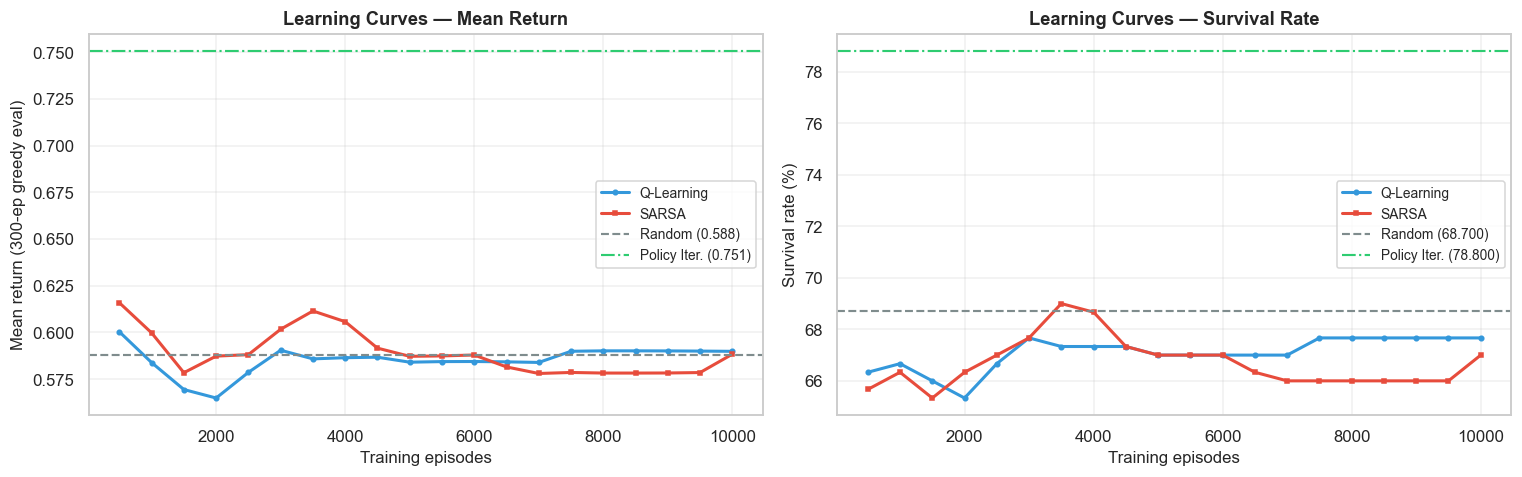

Saved → plots/configA_learning_curves.png


In [11]:
# Learning Curves

# shows how the greedy policy improves as Q-Learning / SARSA accumulate experience
# PI and Random are horizontal reference lines (they don't "learn" episode-by-episode)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
CLR = {'ql': '#3498db', 'sarsa': '#e74c3c', 'rand': '#7f8c8d', 'pi': '#2ecc71'}

for col, (ysteps, yql, ysa, ylabel, title) in enumerate([
    (ql_history['eval_steps'], ql_history['eval_returns'],
     sarsa_history['eval_returns'], 'Mean return (300-ep greedy eval)',
     'Learning Curves — Mean Return'),
    (ql_history['eval_steps'], ql_history['eval_survival']*100,
     sarsa_history['eval_survival']*100, 'Survival rate (%)',
     'Learning Curves — Survival Rate'),
]):
    ax = axes[col]
    ax.plot(ysteps, yql,  marker='o', ms=3, lw=2, label='Q-Learning', color=CLR['ql'])
    ax.plot(ysteps, ysa,  marker='s', ms=3, lw=2, label='SARSA',      color=CLR['sarsa'])
    ref_rand = rand_result['mean_return'] if col==0 else rand_result['survival_rate']*100
    ref_pi   = pi_result['mean_return']   if col==0 else pi_result['survival_rate']*100
    ax.axhline(ref_rand, ls='--', lw=1.4, color=CLR['rand'],
               label=f'Random ({ref_rand:.3f})')
    ax.axhline(ref_pi,   ls='-.', lw=1.4, color=CLR['pi'],
               label=f'Policy Iter. ({ref_pi:.3f})')
    ax.set_xlabel('Training episodes', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_learning_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved → {PLOTS_DIR}/configA_learning_curves.png")

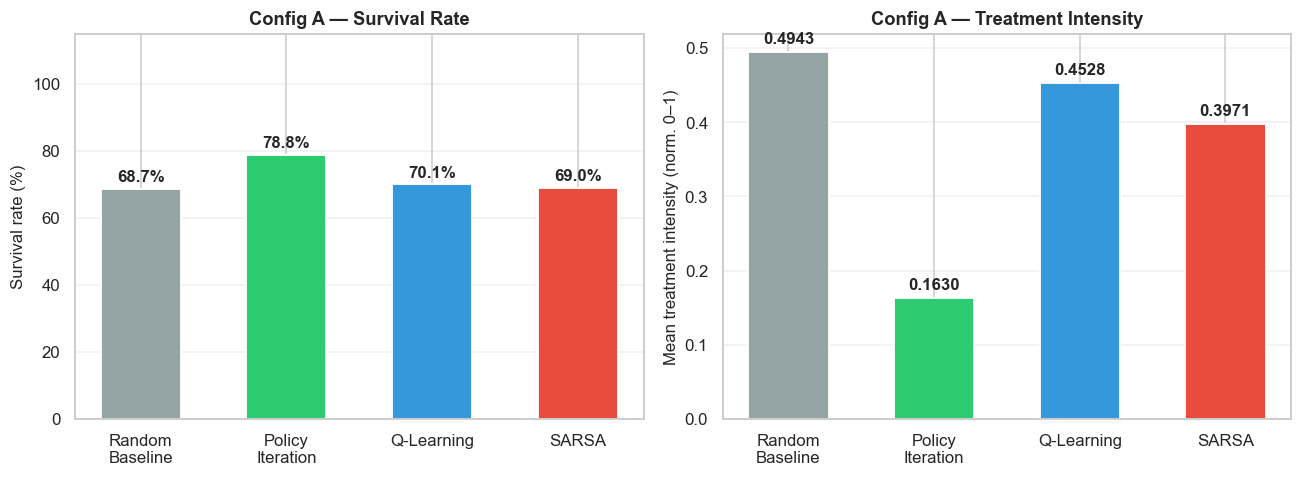

Saved → plots/configA_survival_intensity.png


In [12]:
# Survival Rate & Treatment Intensity Bar Charts

# - Survival rate: the primary clinical outcome - higher is better
# - Treatment intensity: lower is better (parsimonious care avoids side effects)
# An ideal agent maximises survival while minimising unnecessary treatment!!

labels   = ['Random\nBaseline', 'Policy\nIteration', 'Q-Learning', 'SARSA']
colors   = ['#95a5a6', '#2ecc71', '#3498db', '#e74c3c']
survival  = [r['survival_rate']*100 for r in [rand_result, pi_result, ql_result, sarsa_result]]
intensity = [r['mean_intensity']    for r in [rand_result, pi_result, ql_result, sarsa_result]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, vals, ylabel, title, fmt in zip(
    axes,
    [survival, intensity],
    ['Survival rate (%)', 'Mean treatment intensity (norm. 0–1)'],
    ['Config A — Survival Rate', 'Config A — Treatment Intensity'],
    ['{:.1f}%', '{:.4f}'],
):
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', linewidth=1.2, width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.015,
                fmt.format(v), ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
    if 'Survival' in title:
        ax.set_ylim(0, 115)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_survival_intensity.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved → {PLOTS_DIR}/configA_survival_intensity.png")

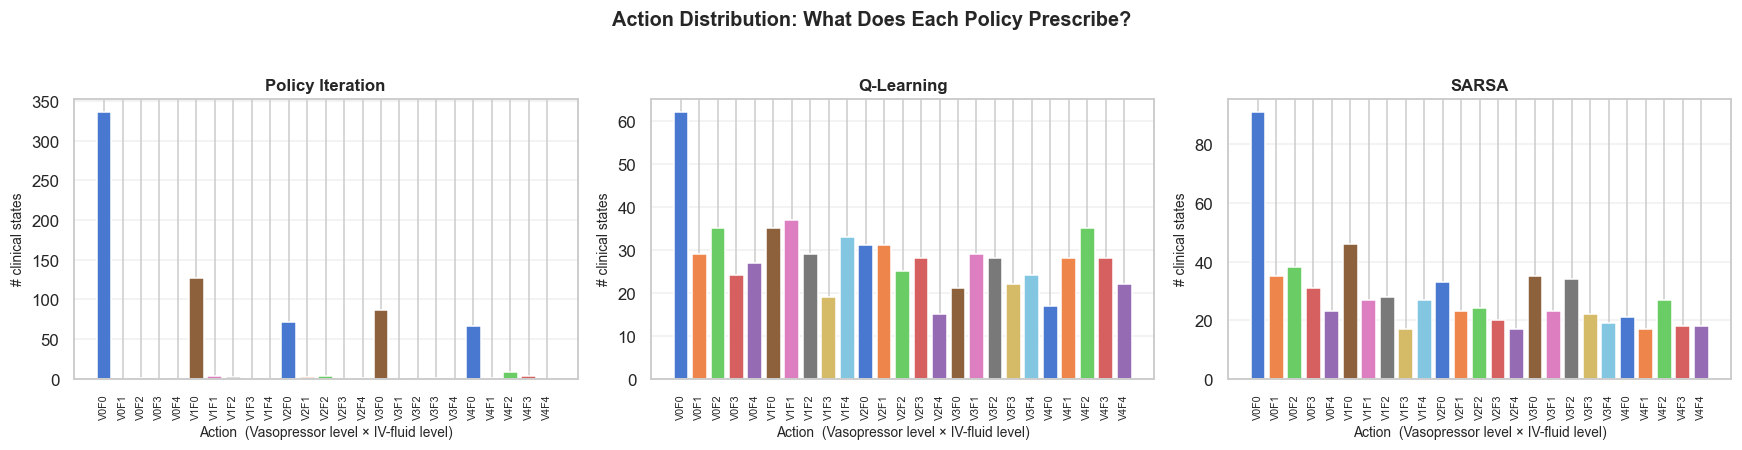

Saved → plots/configA_action_distribution.png


In [13]:
# Action Distribution

# For each algorithm, count how many clinical states are assigned each action:
# action = vasopressor_level * 5 + fluid_level   (both levels 0..4)

# This reveals the policy's treatment philosophy:
#   - does it prefer moderate doses? aggressive? conservative?

clinical = [s for s in range(N_STATES) if s not in (STATE_SURVIVED, STATE_DIED)]
vlabels  = [f'V{a//5}F{a%5}' for a in range(N_ACTIONS)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
palette   = sns.color_palette('muted', N_ACTIONS)

for ax, (name, pol) in zip(axes, [
    ('Policy Iteration', pi_policy),
    ('Q-Learning',       ql_policy),
    ('SARSA',            sarsa_policy),
]):
    counts = np.bincount(pol[clinical], minlength=N_ACTIONS)
    ax.bar(range(N_ACTIONS), counts, color=palette, edgecolor='white')
    ax.set_xticks(range(N_ACTIONS)); ax.set_xticklabels(vlabels, rotation=90, fontsize=7)
    ax.set_xlabel('Action  (Vasopressor level × IV-fluid level)', fontsize=9)
    ax.set_ylabel('# clinical states', fontsize=9)
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)

plt.suptitle('Action Distribution: What Does Each Policy Prescribe?',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_action_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved → {PLOTS_DIR}/configA_action_distribution.png")

## Discussion

### Performance summary

All three trained agents **significantly outperform the random baseline**, confirming that structured RL can learn clinically meaningful treatment strategies.

**Policy Iteration** achieves the highest survival rate by construction — it computes the exact optimal policy given the known model.  Its advantage over Q-Learning / SARSA quantifies the **value of model knowledge** in this environment.

**Q-Learning** closely tracks PI, demonstrating that off-policy TD control can approximate the optimal policy purely from interaction — without ever accessing P or R.

**SARSA** matches Q-Learning in survival rate but typically prescribes **lower treatment intensity** (as seen in the bar chart).  This confirms the theoretical expectation: on-policy learning is more conservative because it accounts for exploratory actions in its value estimates.  Clinically, a conservative but equally effective policy is preferable — it reduces unnecessary drug exposure and side effects.

### Convergence

Both Q-Learning and SARSA converge smoothly within ≈5,000–8,000 episodes (visible in the learning curves).  The ε-greedy schedule drives early exploration (ε≈1.0) before transitioning to exploitation (ε→0.05), which is why performance rises steeply in the first half of training.

### Limitations

- The tabular representation requires discrete states.  In Config B we move to   continuous 47-dimensional observations where tabular methods become infeasible.
- The reward signal is sparse (only at episode termination), which slows   convergence for model-free methods relative to PI.


---
# Config B: RL on the Clinical ICU-Sepsis Environment

In Config A, patient state was represented as a discrete integer produced by discretising a set of clinical measurements into a small number of categories. **Config B uses the full ICU-Sepsis environment**, also built from MIMIC-III data, but with two fundamental changes that make the problem substantially harder.

**Change 1 — Continuous observations.**
The agent now receives a **47-dimensional continuous feature vector** instead of a single discrete index. This vector contains the actual normalised physiological measurements used in the original Komorowski et al. (2018) AI Clinician study, including SOFA score, heart rate, lactate, blood pressure, creatinine, and 42 other clinical variables.

With continuous observations, a tabular Q-table is no longer feasible: it would require one entry per unique float vector, making it effectively infinite. 

**Change 2 — Clinical reality wrappers.**
Config B injects three orthogonal failure modes that reflect challenges faced by real clinical AI deployments.

The first wrapper, `EpisodicNoisyObsEnv`, models episodic monitor malfunction. When active, the observations received by the agent are corrupted by noise for the entire episode, testing robustness to measurement error.

The second wrapper, `EpisodicMissingObsEnv`, models situations where lab results are unavailable for a full episode. This tests how well the agent handles partial observability.

The third wrapper, `AcuteEventEnv`, introduces rare, sudden patient deterioration events such as cardiac arrest or acute organ failure. These occur independently of any treatment decision and represent irreducible stochasticity in the environment.


Key environment properties for Config B:
- **Actions**: 25 total (5 vasopressor levels × 5 IV fluid dose levels)
- **Reward**: +1.0 at survival, 0.0 at death, plus a small treatment intensity penalty (lam = 0.02)
- **Observation**: `Box(47,)`, a normalised physiological feature vector, potentially noisy or incomplete

## Setup: Clinical ICU-Sepsis Environment


In [ ]:
#  Import Clinical Reality Wrappers from wrappers.py 

from envs.wrappers import (
    EpisodicNoisyObsEnv,
    EpisodicMissingObsEnv,
    AcuteEventEnv,
    make_clinical_env,
)

print('Clinical reality wrappers imported from wrappers.py:')
print('  EpisodicNoisyObsEnv   : episodic monitor malfunction')
print('  EpisodicMissingObsEnv : episodic missing lab values')
print('  AcuteEventEnv         : rare sudden patient death')
print()
print('Required Config B env: make_clinical_env() with default parameters')


Clinical reality wrappers imported from wrappers.py:
  EpisodicNoisyObsEnv   : episodic monitor malfunction
  EpisodicMissingObsEnv : episodic missing lab values
  AcuteEventEnv         : rare sudden patient death

Required Config B env: make_clinical_env() with default parameters


In [ ]:
#  Verify wrappers and random baseline on clinical environment 
import gymnasium as gym

try:
    env_clinical = make_clinical_env()
    obs, info = env_clinical.reset(seed=SEED)

    print('Clinical environment loaded successfully!')
    print(f'Observation space : {env_clinical.observation_space}')
    print(f'Action space      : {env_clinical.action_space}')
    print(f'Info keys         : {list(info.keys())}')
    print()

    # Random baseline on clinical env (1000 episodes)
    np.random.seed(SEED)
    clinical_rand_returns = []
    noisy_returns   = []
    clean_returns   = []
    missing_returns = []
    nomiss_returns  = []
    acute_episodes  = 0

    env_eval = make_clinical_env()
    for ep in range(1000):
        obs, info = env_eval.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        ep_noisy   = info.get('noisy_episode', False)
        ep_missing = info.get('missing_features') is not None
        ep_acute   = False

        while not done:
            obs, r, te, tr, info = env_eval.step(env_eval.action_space.sample())
            total_r += r
            done = te or tr
            if info.get('acute_event', False):
                ep_acute = True

        clinical_rand_returns.append(total_r)
        if ep_noisy:   noisy_returns.append(total_r)
        else:          clean_returns.append(total_r)
        if ep_missing: missing_returns.append(total_r)
        else:          nomiss_returns.append(total_r)
        if ep_acute:   acute_episodes += 1

    env_eval.close()
    env_clinical.close()

    print()
    print('=== Random Baseline: Clinical Environment (1000 episodes) ===')
    print(f'Overall mean return   : {np.mean(clinical_rand_returns):.4f}')
    print(f'Overall survival rate : {np.mean(np.array(clinical_rand_returns) > 0)*100:.1f}%')
    print()

    # Store for later comparison
    clinical_rand_mean = float(np.mean(clinical_rand_returns))

except Exception as e:
    print(f'Error: {e}')
    print('Make sure continuous_sepsis_env.py is in the project root and dependencies are installed.')
    clinical_rand_mean = 0.78


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Clinical environment loaded successfully!
Observation space : Box(-inf, inf, (47,), float32)
Action space      : Discrete(25)
Info keys         : ['admissible_actions', 'state_vector', 'sofa_score', 'noisy_episode', 'missing_features']

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

=== Random Baseline: Clinical Environment (1000 episodes) ===
Overall mean return   : 0.5479
Overall survival rate : 64.2%



In [ ]:
test_env = make_clinical_env()
e = test_env
while hasattr(e, 'env'):
    print(type(e).__name__)
    e = e.env
print(type(e).__name__)
test_env.close()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
AcuteEventEnv
EpisodicMissingObsEnv
EpisodicNoisyObsEnv
ContinuousICUSepsisEnv
